<a href="https://colab.research.google.com/github/ankurdev1-drth/Deep_Learning-/blob/main/02_Training_Deep_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [1]:
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import torch

layer = nn.Linear(40, 10)
layer.weight.data *= 6 ** 0.5  # kaiming init (or 3 ** 0.5 for LeCun)
torch.zero_(layer.bias.data)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [3]:
layer.weight.shape

torch.Size([10, 40])

In [4]:
layer.bias.shape

torch.Size([10])

In [5]:
# another way to for initialization
nn.init.kaiming_uniform_(layer.weight)
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)

This is clearer and less error prone as compared to the first approach

For applying initialization to the weights of every `nn.Linear` layer in a model the simples option is to write a little function that takes a module, checks whether it's an instance of the `nn.Linear` class, and if so , applies the desired initialization function to its weights. and the function can be then applied using the `apply()` method

In [6]:
def use_he_init(module):
  if isinstance(module, nn.Linear):
    nn.init.kaiming_uniform_(module.weight)
    nn.init.zeros_(module.bias)

module = nn.Sequential(
    nn.Linear(40, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
    nn.ReLU()
    )
module.apply(use_he_init)

Sequential(
  (0): Linear(in_features=40, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=1, bias=True)
  (3): ReLU()
)

### Leaky ReLU

In [7]:
alpha = 0.2
model = nn.Sequential(
    nn.Linear(50, 40), #0
    nn.LeakyReLU(negative_slope=alpha), #1
    nn.Linear(40, 20), #2
    nn.LeakyReLU(negative_slope=alpha) #3

)
nn.init.kaiming_uniform_(model[0].weight, alpha,
nonlinearity="leaky_relu")
nn.init.kaiming_uniform_(model[2].weight, alpha,nonlinearity="leaky_relu")

Parameter containing:
tensor([[-0.2893, -0.2045, -0.1845,  0.2131,  0.1407,  0.2897,  0.3132,  0.1023,
          0.0735, -0.0324,  0.1953,  0.1194, -0.3055,  0.2489, -0.2058, -0.2409,
         -0.2759, -0.3457, -0.1921,  0.1131,  0.0656, -0.1731, -0.0291,  0.2551,
          0.0553,  0.3522,  0.2765, -0.3440, -0.1545, -0.0018,  0.1437, -0.3154,
          0.0124,  0.0807, -0.2502,  0.1081,  0.1401,  0.3570,  0.1832,  0.0645],
        [ 0.3132,  0.3259, -0.0073,  0.2292, -0.2652,  0.0056,  0.1158,  0.1828,
         -0.3348, -0.3085,  0.1423, -0.2452,  0.3104, -0.1797, -0.0380, -0.3135,
          0.2684, -0.2305, -0.3663,  0.3491,  0.2978,  0.1011,  0.0064, -0.2660,
          0.3112,  0.0385,  0.3318,  0.0330, -0.2527,  0.0113, -0.1338, -0.1372,
          0.0505,  0.1710, -0.2001, -0.0674,  0.3133, -0.1174, -0.0724,  0.0462],
        [ 0.2991,  0.2747, -0.0457, -0.2773, -0.0908,  0.2079, -0.3398, -0.2323,
          0.1937,  0.3138, -0.0266, -0.0975, -0.0605, -0.2744,  0.1918, -0.3625,
    

### Batch Normalization

In [8]:
model = nn.Sequential(
    nn.Flatten(),
    nn.BatchNorm1d(1 * 28 * 28),
    nn.Linear(1 * 28 * 28,  300),
    nn.ReLU(),
    nn.BatchNorm1d(300),
    nn.Linear(300, 100),
    nn.ReLU(),
    nn.BatchNorm1d(100),
    nn.Linear(100, 10)
)

In [9]:
dict(model[1].named_parameters()).keys()

dict_keys(['weight', 'bias'])

In [10]:
dict(model[1].named_buffers()).keys()

dict_keys(['running_mean', 'running_var', 'num_batches_tracked'])

In [11]:
dict(model[1].named_children()).keys()

dict_keys([])

In [12]:
dict(model[1].named_modules()).keys()

dict_keys([''])

Note:
- if BN layers before the activation functions, we can also remove the bias term from the previous `nn.Linear` layers by setting the `bias` hyperparameter to `False`.

In [13]:
Model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 300, bias=False),
    nn.BatchNorm1d(300),
    nn.ReLU(),
    nn.Linear(300, 100, bias=False),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Linear(100, 10)
)

### Layer Normalization

In [14]:
inputs = torch.randn(32, 3, 100, 200)   # batch of random RGB images
layer_norm = nn.LayerNorm([100, 200])
result = layer_norm(inputs)
result

tensor([[[[ 0.2755, -1.3820, -1.0615,  ...,  0.5643, -1.3474,  0.1224],
          [-0.6564, -1.5349, -0.8335,  ...,  1.4387,  0.1519, -0.1260],
          [-1.3223,  1.1836, -0.7631,  ...,  0.2066, -0.5577,  0.4988],
          ...,
          [-0.9771,  1.2619,  0.3769,  ..., -1.2526, -0.5878, -0.2494],
          [ 1.3404,  0.4871,  0.3841,  ...,  0.1206, -0.0127,  0.3766],
          [-2.2418, -0.9107, -1.6007,  ..., -0.6599,  0.8884, -0.5698]],

         [[ 0.1970,  0.1820,  1.9322,  ..., -0.9304,  0.7403, -1.8109],
          [ 0.7142,  0.2795, -0.0700,  ...,  1.0564, -0.1716, -0.4269],
          [ 0.3522,  0.6309, -1.0758,  ...,  0.8890,  1.1210, -2.4442],
          ...,
          [-0.9908, -0.0253, -0.8723,  ..., -0.1817,  0.5362,  0.5330],
          [-0.3802, -0.1378,  1.3743,  ...,  0.1123,  0.3925, -0.6320],
          [-2.0150,  0.5482, -0.6482,  ..., -1.9947,  0.2576,  0.3830]],

         [[-1.2569, -0.5620,  2.2503,  ..., -0.5983,  0.0285,  0.5193],
          [ 0.2936, -1.2055, -

In [15]:
# method 2 to perform the same thing as above!
means = inputs.mean(dim=[2,3], keepdim=True)  #shape [32, 3, 1, 1]
vars_ = inputs.var(dim=[2,3], keepdim=True, unbiased=False) # shape: same
stds = torch.sqrt(vars_ + layer_norm.eps) # eps is a smoothing term (1e-5)
result = layer_norm.weight * (inputs - means) / stds + layer_norm.bias

In [16]:
layer_norm = nn.LayerNorm([3, 100, 200])
result = layer_norm(inputs)

In [17]:
result

tensor([[[[ 0.2682, -1.3913, -1.0704,  ...,  0.5573, -1.3567,  0.1149],
          [-0.6649, -1.5444, -0.8422,  ...,  1.4327,  0.1444, -0.1338],
          [-1.3316,  1.1773, -0.7717,  ...,  0.1992, -0.5660,  0.4917],
          ...,
          [-0.9859,  1.2558,  0.3697,  ..., -1.2618, -0.5962, -0.2573],
          [ 1.3343,  0.4801,  0.3769,  ...,  0.1130, -0.0204,  0.3694],
          [-2.2522, -0.9195, -1.6103,  ..., -0.6684,  0.8818, -0.5782]],

         [[ 0.1962,  0.1812,  1.9276,  ..., -0.9288,  0.7383, -1.8074],
          [ 0.7122,  0.2785, -0.0702,  ...,  1.0537, -0.1716, -0.4264],
          [ 0.3510,  0.6291, -1.0738,  ...,  0.8867,  1.1182, -2.4393],
          ...,
          [-0.9890, -0.0257, -0.8708,  ..., -0.1817,  0.5346,  0.5314],
          [-0.3797, -0.1379,  1.3709,  ...,  0.1117,  0.3913, -0.6310],
          [-2.0110,  0.5466, -0.6472,  ..., -1.9908,  0.2566,  0.3818]],

         [[-1.2500, -0.5545,  2.2604,  ..., -0.5908,  0.0366,  0.5278],
          [ 0.3019, -1.1986, -

## Gradient Clipping

See the line nn.utils.clip_grad_norm_(...) in the training function in the next section.

# Reusing Pretrained Layers

### Transfer Learning with PyTorch

- X_train_A = images of all items except for T-shirts/tops and pullovers (classes 0 and 2 )
- X_train_B = first 20 images of Tshirt and Pullovers

The validation set and the test set are also split this way, but without restricting the number of images.

We will train a model on set A (classification task with 8 classes), and try to reuse it to tackle set B (binary classification). We hope to transfer a little bit of knowledge from task A to task B, since classes in set A (trousers, dresses, coats, sandals, shirts, sneakers, bags, and ankle boots) are somewhat similar to classes in set B (T-shirts/tops and pullovers). However, since we are using Linear layers, only patterns that occur at the same location can be reused (in contrast, convolutional layers will transfer much better, since learned patterns can be detected anywhere on the image)


In [18]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml


fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False) #as_frames = False for getting the numpy arrays instead of pandas dataframe/series
X = torch.FloatTensor(fashion_mnist.data.reshape(-1, 1, 28, 28) / 255.)
y = torch.from_numpy(fashion_mnist.target.astype(int))
in_B = (y == 0) | (y == 2)  # Pullover or T-shirt/top
X_A, y_A = X[~in_B], y[~in_B]
y_A = torch.maximum(y_A - 2, torch.tensor(0))  # [1,3,4,5,6,7,8,9] => [0,..,7]
X_B, y_B = X[in_B], (y[in_B] == 2).to(dtype=torch.float32).view(-1, 1)

train_set_A = TensorDataset(X_A[:-7_000], y_A[:-7000])
valid_set_A = TensorDataset(X_A[-7_000:-5000], y_A[-7000:-5000])
test_set_A = TensorDataset(X_A[-5_000:], y_A[-5000:])
train_set_B = TensorDataset(X_B[:20], y_B[:20])
valid_set_B = TensorDataset(X_B[20:5000], y_B[20:5000])
test_set_B = TensorDataset(X_B[5_000:], y_B[5000:])

train_loader_A = DataLoader(train_set_A, batch_size=32, shuffle=True)
valid_loader_A = DataLoader(valid_set_A, batch_size=32)
test_loader_A = DataLoader(test_set_A, batch_size=32)
train_loader_B = DataLoader(train_set_B, batch_size=32, shuffle=True)
valid_loader_B = DataLoader(valid_set_B, batch_size=32)
test_loader_B = DataLoader(test_set_B, batch_size=32)

In [19]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device


'cuda'

In [20]:
%pip install torchmetrics


import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            # Uncomment to activate gradient clipping:
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.7 MB/s eta 0:00:00


In [21]:
torch.manual_seed(42)

model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 8)
  )
model_A = model_A.to(device)

In [22]:
model_A.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=8, bias=True)
)

In [23]:
n_epochs = 20
optimizer = torch.optim.SGD(model_A.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=8).to(device)
history_A = train(model_A, optimizer, loss_fn, accuracy, train_loader_A, valid_loader_A, n_epochs )

Epoch 1/20, train loss: 0.8637, train metric: 0.7116, valid metric: 0.8265
Epoch 2/20, train loss: 0.4608, train metric: 0.8462, valid metric: 0.8575
Epoch 3/20, train loss: 0.3836, train metric: 0.8700, valid metric: 0.8730
Epoch 4/20, train loss: 0.3466, train metric: 0.8821, valid metric: 0.8825
Epoch 5/20, train loss: 0.3236, train metric: 0.8883, valid metric: 0.8935
Epoch 6/20, train loss: 0.3081, train metric: 0.8934, valid metric: 0.8930
Epoch 7/20, train loss: 0.2958, train metric: 0.8976, valid metric: 0.8905
Epoch 8/20, train loss: 0.2861, train metric: 0.9006, valid metric: 0.9015
Epoch 9/20, train loss: 0.2784, train metric: 0.9036, valid metric: 0.8985
Epoch 10/20, train loss: 0.2708, train metric: 0.9067, valid metric: 0.8955
Epoch 11/20, train loss: 0.2658, train metric: 0.9085, valid metric: 0.9050
Epoch 12/20, train loss: 0.2595, train metric: 0.9095, valid metric: 0.8990
Epoch 13/20, train loss: 0.2548, train metric: 0.9120, valid metric: 0.9075
Epoch 14/20, train lo

In [24]:
torch.manual_seed(42)
model_B = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
).to(device)

In [25]:
model_B.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=1, bias=True)
)

In [26]:
n_epochs = 20
optimizer = torch.optim.SGD(model_B.parameters(), lr=0.001)
loss_fn = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B, optimizer, loss_fn, accuracy, train_loader_B, valid_loader_B, n_epochs)

Epoch 1/20, train loss: 0.7446, train metric: 0.6000, valid metric: 0.4970
Epoch 2/20, train loss: 0.7421, train metric: 0.6000, valid metric: 0.4970
Epoch 3/20, train loss: 0.7397, train metric: 0.6000, valid metric: 0.4970
Epoch 4/20, train loss: 0.7372, train metric: 0.6000, valid metric: 0.4970
Epoch 5/20, train loss: 0.7348, train metric: 0.6000, valid metric: 0.4970
Epoch 6/20, train loss: 0.7324, train metric: 0.6000, valid metric: 0.4970
Epoch 7/20, train loss: 0.7300, train metric: 0.6000, valid metric: 0.4970
Epoch 8/20, train loss: 0.7276, train metric: 0.6000, valid metric: 0.4970
Epoch 9/20, train loss: 0.7252, train metric: 0.6000, valid metric: 0.4970
Epoch 10/20, train loss: 0.7228, train metric: 0.6000, valid metric: 0.4970
Epoch 11/20, train loss: 0.7205, train metric: 0.6000, valid metric: 0.4970
Epoch 12/20, train loss: 0.7181, train metric: 0.6000, valid metric: 0.4970
Epoch 13/20, train loss: 0.7157, train metric: 0.6000, valid metric: 0.4970
Epoch 14/20, train lo

In [27]:
# reusing all the layers except the output layer
import copy

torch.manual_seed(42)
reused_layer = copy.deepcopy(model_A[: -1])
model_B_on_A = nn.Sequential(
    *reused_layer,
    nn.Linear(100, 1) # new output layer for task B
).to(device)

Note:
- `copy.deepcopy()` function to copy all the modules and submodules in `nn.Sequential` module
- model_B_on_A is another `nn.Sequential` module based on the reused layers of model A plus a new output layer for task B it has a single output since task B is binary classification.

In [28]:
# freezing the reused layers during the first few epochs:
for layer in model_B_on_A[:-1]:
  for param in layer.parameters():
    param.requires_grad = False


In [29]:
n_epochs = 10
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B_on_A, optimizer, xentropy, accuracy,
                  train_loader_B, valid_loader_B, n_epochs)

Epoch 1/10, train loss: 0.9154, train metric: 0.4000, valid metric: 0.4839
Epoch 2/10, train loss: 0.8790, train metric: 0.4000, valid metric: 0.4753
Epoch 3/10, train loss: 0.8462, train metric: 0.3500, valid metric: 0.4550
Epoch 4/10, train loss: 0.8174, train metric: 0.4500, valid metric: 0.4207
Epoch 5/10, train loss: 0.7924, train metric: 0.4500, valid metric: 0.3775
Epoch 6/10, train loss: 0.7712, train metric: 0.5500, valid metric: 0.3036
Epoch 7/10, train loss: 0.7536, train metric: 0.5500, valid metric: 0.2739
Epoch 8/10, train loss: 0.7392, train metric: 0.4000, valid metric: 0.2835
Epoch 9/10, train loss: 0.7271, train metric: 0.3500, valid metric: 0.3177
Epoch 10/10, train loss: 0.7165, train metric: 0.4000, valid metric: 0.3482


In [30]:
# unfreezing the reused layers during the first few epochs:
for layer in model_B_on_A[2:]:
  for param in layer.parameters():
    param.requires_grad = True

In [31]:
n_epochs = 20
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.01)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B_on_A, optimizer, xentropy, accuracy,
                train_loader_B, valid_loader_B, n_epochs)

Epoch 1/20, train loss: 0.7065, train metric: 0.4000, valid metric: 0.3980
Epoch 2/20, train loss: 0.6840, train metric: 0.4000, valid metric: 0.4275
Epoch 3/20, train loss: 0.6623, train metric: 0.5500, valid metric: 0.4546
Epoch 4/20, train loss: 0.6413, train metric: 0.6500, valid metric: 0.4857
Epoch 5/20, train loss: 0.6209, train metric: 0.7000, valid metric: 0.5243
Epoch 6/20, train loss: 0.6012, train metric: 0.7500, valid metric: 0.5709
Epoch 7/20, train loss: 0.5819, train metric: 0.8000, valid metric: 0.6104
Epoch 8/20, train loss: 0.5632, train metric: 0.9000, valid metric: 0.6580
Epoch 9/20, train loss: 0.5451, train metric: 0.9000, valid metric: 0.6982
Epoch 10/20, train loss: 0.5276, train metric: 0.9000, valid metric: 0.7305
Epoch 11/20, train loss: 0.5106, train metric: 0.9500, valid metric: 0.7592
Epoch 12/20, train loss: 0.4941, train metric: 0.9500, valid metric: 0.7799
Epoch 13/20, train loss: 0.4782, train metric: 0.9500, valid metric: 0.8000
Epoch 14/20, train lo

In [32]:
evaluate_tm(model_B_on_A, test_loader_B, accuracy)

tensor(0.8797, device='cuda:0')

## Faster Optimizers

In [33]:

def build_model(seed=43):
  torch.manual_seed(seed)
  model = nn.Sequential(
      nn.Flatten(),
      nn.Linear(28 * 28, 100),
      nn.ReLU(),
      nn.Linear(100, 100),
      nn.ReLU(),
      nn.Linear(100, 100),
      nn.ReLU(),
      nn.Linear(100, 10)
  ).to(device)
  model.apply(use_he_init)
  return model

def test_optimizer(model, optimizer, n_epochs=10, batch_size=32):
  train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
  valid_loader = DataLoader(valid_set, batch_size=batch_size)
  test_loader = DataLoader(test_set, batch_size=32)
  xentropy = nn.CrossEntropyLoss()
  accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
  history = train(model, optimizer, xentropy, accuracy.to(device),
                  train_loader, valid_loader, n_epochs)
  return history, evaluate_tm(model, test_loader, accuracy)


In [34]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## Momentum Optimization

In [35]:
train_set = TensorDataset(X[:55_000], y[:55_000])
valid_set = TensorDataset(X[55_000:60_000], y[55_000:60_000])
test_set = TensorDataset(X[60_000:], y[60_000:])

model = build_model()
optimizer = torch.optim.SGD(model.parameters(), momentum=0.9, lr=0.01)
history_momentum, accuracy_momentum = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.5734, train metric: 0.7995, valid metric: 0.8404
Epoch 2/10, train loss: 0.4154, train metric: 0.8519, valid metric: 0.8242
Epoch 3/10, train loss: 0.3729, train metric: 0.8655, valid metric: 0.8580
Epoch 4/10, train loss: 0.3501, train metric: 0.8735, valid metric: 0.8660
Epoch 5/10, train loss: 0.3290, train metric: 0.8805, valid metric: 0.8660
Epoch 6/10, train loss: 0.3134, train metric: 0.8854, valid metric: 0.8714
Epoch 7/10, train loss: 0.3010, train metric: 0.8887, valid metric: 0.8638
Epoch 8/10, train loss: 0.2904, train metric: 0.8931, valid metric: 0.8746
Epoch 9/10, train loss: 0.2798, train metric: 0.8959, valid metric: 0.8640
Epoch 10/10, train loss: 0.2704, train metric: 0.9006, valid metric: 0.8786


### Nesterov Accelerated Gradient

In [36]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), momentum=0.9, nesterov=True, lr=0.01)
history_nesterov, accuracy_nesterov = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.5579, train metric: 0.8066, valid metric: 0.8408
Epoch 2/10, train loss: 0.4102, train metric: 0.8541, valid metric: 0.8254
Epoch 3/10, train loss: 0.3697, train metric: 0.8671, valid metric: 0.8656
Epoch 4/10, train loss: 0.3457, train metric: 0.8751, valid metric: 0.8734
Epoch 5/10, train loss: 0.3257, train metric: 0.8818, valid metric: 0.8710
Epoch 6/10, train loss: 0.3110, train metric: 0.8869, valid metric: 0.8700
Epoch 7/10, train loss: 0.2970, train metric: 0.8904, valid metric: 0.8660
Epoch 8/10, train loss: 0.2870, train metric: 0.8949, valid metric: 0.8772
Epoch 9/10, train loss: 0.2773, train metric: 0.8972, valid metric: 0.8724
Epoch 10/10, train loss: 0.2681, train metric: 0.9012, valid metric: 0.8710


## AdaGrad

In [37]:
model = build_model()
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01)
history_adagrad, accuracy_adagrad = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.4860, train metric: 0.8253, valid metric: 0.8562
Epoch 2/10, train loss: 0.3657, train metric: 0.8688, valid metric: 0.8608
Epoch 3/10, train loss: 0.3348, train metric: 0.8791, valid metric: 0.8738
Epoch 4/10, train loss: 0.3163, train metric: 0.8861, valid metric: 0.8800
Epoch 5/10, train loss: 0.3017, train metric: 0.8910, valid metric: 0.8794
Epoch 6/10, train loss: 0.2910, train metric: 0.8945, valid metric: 0.8842
Epoch 7/10, train loss: 0.2810, train metric: 0.8989, valid metric: 0.8808
Epoch 8/10, train loss: 0.2740, train metric: 0.9004, valid metric: 0.8822
Epoch 9/10, train loss: 0.2669, train metric: 0.9031, valid metric: 0.8772
Epoch 10/10, train loss: 0.2614, train metric: 0.9052, valid metric: 0.8836


## RMSProp

In [38]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.01, alpha=0.9)
history_rmsprop, accuracy_rmsprop = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.7515, train metric: 0.7639, valid metric: 0.8042
Epoch 2/10, train loss: 0.6448, train metric: 0.8115, valid metric: 0.8226
Epoch 3/10, train loss: 0.6809, train metric: 0.8174, valid metric: 0.7864
Epoch 4/10, train loss: 0.6983, train metric: 0.8229, valid metric: 0.8170
Epoch 5/10, train loss: 0.7113, train metric: 0.8244, valid metric: 0.7624
Epoch 6/10, train loss: 0.7675, train metric: 0.8216, valid metric: 0.7830
Epoch 7/10, train loss: 0.8224, train metric: 0.8221, valid metric: 0.8368
Epoch 8/10, train loss: 0.8782, train metric: 0.8215, valid metric: 0.8238
Epoch 9/10, train loss: 0.8489, train metric: 0.8193, valid metric: 0.7978
Epoch 10/10, train loss: 0.9099, train metric: 0.8136, valid metric: 0.8386


## Adam Optimization

In [39]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05, betas=(0.9, 0.999))
history_adam, accuracy_adam = test_optimizer(model, optimizer)


Epoch 1/10, train loss: 1.7182, train metric: 0.4202, valid metric: 0.4462
Epoch 2/10, train loss: 1.6880, train metric: 0.3931, valid metric: 0.4276
Epoch 3/10, train loss: 1.3446, train metric: 0.4381, valid metric: 0.4566
Epoch 4/10, train loss: 1.3007, train metric: 0.4479, valid metric: 0.4432
Epoch 5/10, train loss: 1.2511, train metric: 0.4526, valid metric: 0.3894
Epoch 6/10, train loss: 1.2445, train metric: 0.4489, valid metric: 0.4534
Epoch 7/10, train loss: 1.2919, train metric: 0.4467, valid metric: 0.4278
Epoch 8/10, train loss: 1.3447, train metric: 0.4402, valid metric: 0.3350
Epoch 9/10, train loss: 1.6452, train metric: 0.3579, valid metric: 0.3200
Epoch 10/10, train loss: 1.5717, train metric: 0.3528, valid metric: 0.3442


### Adamax Optimization

In [40]:
model =  build_model()
optimizer = torch.optim.Adamax(model.parameters(), lr=0.03, betas=(0.9, 0.999))
history_adamax, accuracy_adamax = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.6025, train metric: 0.7987, valid metric: 0.8214
Epoch 2/10, train loss: 0.4362, train metric: 0.8457, valid metric: 0.8356
Epoch 3/10, train loss: 0.4077, train metric: 0.8552, valid metric: 0.8592
Epoch 4/10, train loss: 0.3883, train metric: 0.8603, valid metric: 0.8606
Epoch 5/10, train loss: 0.3729, train metric: 0.8665, valid metric: 0.8562
Epoch 6/10, train loss: 0.3620, train metric: 0.8716, valid metric: 0.8652
Epoch 7/10, train loss: 0.3492, train metric: 0.8740, valid metric: 0.8308
Epoch 8/10, train loss: 0.3436, train metric: 0.8763, valid metric: 0.8720
Epoch 9/10, train loss: 0.3337, train metric: 0.8797, valid metric: 0.8608
Epoch 10/10, train loss: 0.3267, train metric: 0.8820, valid metric: 0.8718


### Nadam Optimization

In [41]:
model = build_model()  # extra code
optimizer = torch.optim.NAdam(model.parameters(), betas=(0.9, 0.999), lr=0.05)
history_nadam, acc_nadam = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 1.8024, train metric: 0.3014, valid metric: 0.2950
Epoch 2/10, train loss: 1.9952, train metric: 0.3210, valid metric: 0.3212
Epoch 3/10, train loss: 1.7227, train metric: 0.3037, valid metric: 0.3160
Epoch 4/10, train loss: 1.6206, train metric: 0.3283, valid metric: 0.3162
Epoch 5/10, train loss: 1.6928, train metric: 0.3080, valid metric: 0.3124
Epoch 6/10, train loss: 1.6427, train metric: 0.3243, valid metric: 0.3292
Epoch 7/10, train loss: 1.6526, train metric: 0.3178, valid metric: 0.3142
Epoch 8/10, train loss: 1.6718, train metric: 0.3121, valid metric: 0.3014
Epoch 9/10, train loss: 1.6576, train metric: 0.3164, valid metric: 0.3042
Epoch 10/10, train loss: 1.6773, train metric: 0.3119, valid metric: 0.2996


### AdamW Optimization

In [42]:
model = build_model()
optimizer = torch.optim.AdamW(model.parameters(), betas=(0.9, 0.999), lr=0.03)
history_adamW, accuracy_adamw = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.8904, train metric: 0.6988, valid metric: 0.6810
Epoch 2/10, train loss: 0.6955, train metric: 0.7471, valid metric: 0.7420
Epoch 3/10, train loss: 0.6608, train metric: 0.7617, valid metric: 0.7992
Epoch 4/10, train loss: 0.6384, train metric: 0.7790, valid metric: 0.8014
Epoch 5/10, train loss: 0.6496, train metric: 0.7768, valid metric: 0.7672
Epoch 6/10, train loss: 0.6450, train metric: 0.7815, valid metric: 0.8014
Epoch 7/10, train loss: 0.6963, train metric: 0.7603, valid metric: 0.7468
Epoch 8/10, train loss: 0.7208, train metric: 0.7370, valid metric: 0.7502
Epoch 9/10, train loss: 0.6952, train metric: 0.7437, valid metric: 0.7518
Epoch 10/10, train loss: 0.6961, train metric: 0.7442, valid metric: 0.7540


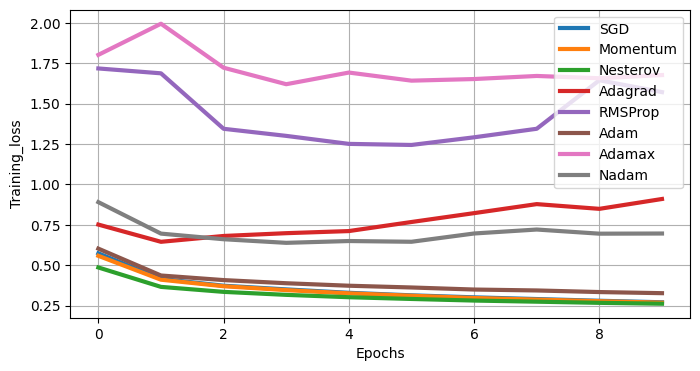

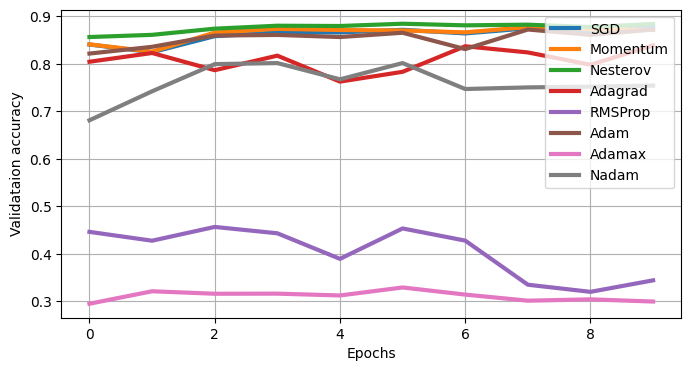

In [43]:
for plot in ("train_losses", "valid_metrics"):
  plt.figure(figsize=(8,4))
  opt_names = "SGD Momentum Nesterov Adagrad RMSProp Adam Adamax Nadam AdamW".split()
  for history, opt_name in zip(
      (history_momentum, history_nesterov, history_adagrad,
       history_rmsprop, history_adam, history_adamax, history_nadam,
       history_adamW), opt_names):
       plt.plot(history[plot], label=opt_name, linewidth=3)

  plt.grid()
  plt.xlabel("Epochs")
  plt.ylabel({"train_losses": "Training_loss", "valid_metrics": "Validataion accuracy"}[plot])
  plt.legend(loc="upper right")
  plt.show()

## Learning Rate Scheduling